# Model Example 1: Regression — Predicting House Prices
This notebook walks through building a **regression model** end-to-end, hitting the core steps that matter when creating any ML model: data representation, splitting, feature engineering, training, evaluation, and tuning.

# Data Representation in Machine Learning
Every model needs data organized into a **features matrix** (`X`) and a **target array** (`y`). We'll use the California Housing dataset from scikit-learn.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split, GridSearchCV, learning_curve
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

data = load_diabetes(as_frame=True)
df = data.frame

X = df.drop(columns=["target"])   # Features matrix
y = df["target"]                  # Target array

print("Features matrix shape:", X.shape)
print("Target array shape:", y.shape)
X.head()


Features matrix shape: (442, 10)
Target array shape: (442,)


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641


## Features matrix
`X` holds every predictor column (age, BMI, blood pressure, and blood serum measurements) — one row per sample, one column per feature.

## Target array
`y` holds the single value we're trying to predict — here, disease progression score.

# Handling Missing Values
Real datasets often have gaps. We inject a few missing values on purpose and show how a `SimpleImputer` fills them so the model doesn't break on `NaN`.

In [2]:
# Simulate a couple of missing values to demonstrate imputation
rng = np.random.RandomState(0)
X_demo = X.copy()
missing_idx = rng.choice(X_demo.index, size=50, replace=False)
X_demo.loc[missing_idx, "bmi"] = np.nan

print("Missing values before imputation:", X_demo["bmi"].isna().sum())

imputer = SimpleImputer(strategy="median")
X_demo["bmi"] = imputer.fit_transform(X_demo[["bmi"]])

print("Missing values after imputation:", X_demo["bmi"].isna().sum())


Missing values before imputation: 50
Missing values after imputation: 0


# Handling Numerical Data
Features here live on different scales after mean-centering by scikit-learn, and real-world versions would include even more disparate units (age in years vs. blood pressure in mmHg). `StandardScaler` centers and scales them so no single feature dominates training.

# Dataset Division or Splitting
## 1. Why Split Data?
If we train and evaluate on the same rows, we can't tell whether the model actually generalizes — it might just be memorizing. Splitting gives us an honest, unseen test set.

## 2. Common Splitting Strategies
The most common approach is a random **train/test split** (e.g. 80/20). For small datasets or model selection, k-fold cross-validation is common too.

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print("Train size:", X_train.shape[0], " Test size:", X_test.shape[0])


Train size: 353  Test size: 89


# Feature Pipelines
Instead of manually imputing then scaling then fitting, we chain every step into a single `Pipeline`. This keeps preprocessing and modeling glued together and prevents data leakage between train and test.

In [4]:
pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", LinearRegression())
])

pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_test)
print("Pipeline trained.")


Pipeline trained.


# Model Development
We fit a **Linear Regression** model — a simple, interpretable baseline for regression problems — using the pipeline above so preprocessing happens automatically on both train and test data.

# Model Performance Metrics
No single metric tells the whole story. We check three of the most common regression metrics below.

## Mean Squared Error
Squares each error before averaging, so large mistakes are penalized disproportionately more than small ones.

In [5]:
mse = mean_squared_error(y_test, y_pred)
print(f"Mean Squared Error: {mse:.3f}")


Mean Squared Error: 2900.194


## Mean Absolute Error (MAE)
The average absolute difference between predicted and actual values — easier to interpret directly in the target's original units.

In [6]:
mae = mean_absolute_error(y_test, y_pred)
print(f"Mean Absolute Error: {mae:.3f}")


Mean Absolute Error: 42.794


## R-squared (R²)
The proportion of variance in the target explained by the model. 1.0 is a perfect fit; 0.0 means the model does no better than predicting the mean.

In [7]:
r2 = r2_score(y_test, y_pred)
print(f"R-squared: {r2:.3f}")


R-squared: 0.453


# Learning Curves
A learning curve shows training vs. validation error as training set size grows. It tells us whether the model would benefit from more data, or whether it's underfitting/overfitting.

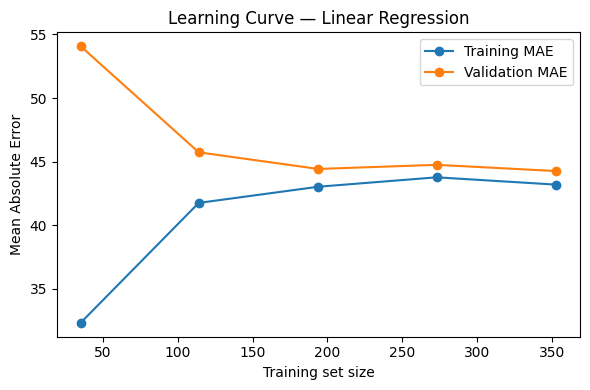

In [8]:
train_sizes, train_scores, val_scores = learning_curve(
    pipeline, X, y, cv=5, scoring="neg_mean_absolute_error",
    train_sizes=np.linspace(0.1, 1.0, 5), random_state=42
)

train_mae = -train_scores.mean(axis=1)
val_mae = -val_scores.mean(axis=1)

plt.figure(figsize=(6, 4))
plt.plot(train_sizes, train_mae, "o-", label="Training MAE")
plt.plot(train_sizes, val_mae, "o-", label="Validation MAE")
plt.xlabel("Training set size")
plt.ylabel("Mean Absolute Error")
plt.title("Learning Curve — Linear Regression")
plt.legend()
plt.tight_layout()
plt.show()


# Validation in Practice: Grid Search
To pick the best model configuration, we search over hyperparameters using cross-validation rather than guessing. Here we tune Ridge regression's regularization strength `alpha`.

In [9]:
param_grid = {"model__alpha": [0.01, 0.1, 1.0, 10.0, 100.0]}

ridge_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", Ridge())
])

grid_search = GridSearchCV(
    ridge_pipeline, param_grid, cv=5, scoring="neg_mean_absolute_error"
)
grid_search.fit(X_train, y_train)

print("Best alpha:", grid_search.best_params_)
print("Best CV MAE:", -grid_search.best_score_)


Best alpha: {'model__alpha': 10.0}
Best CV MAE: 45.40145594414554


# Selecting the Best Model
We compare the plain Linear Regression baseline against the tuned Ridge model on the held-out test set, and pick whichever generalizes better.

In [10]:
best_model = grid_search.best_estimator_
y_pred_best = best_model.predict(X_test)

print("Linear Regression -> MAE: {:.3f}, R2: {:.3f}".format(mae, r2))
print("Tuned Ridge        -> MAE: {:.3f}, R2: {:.3f}".format(
    mean_absolute_error(y_test, y_pred_best),
    r2_score(y_test, y_pred_best)
))


Linear Regression -> MAE: 42.794, R2: 0.453
Tuned Ridge        -> MAE: 42.857, R2: 0.457
